In [14]:
import glob as glob
import pandas as pd
import os

# load in a envelope
acoustics = '../../TS_acoustics'
envelopes = glob.glob(acoustics + '/env_*.csv')
print(envelopes)
example = 1
envtest = pd.read_csv(envelopes[example])
envtest.head()


['../../TS_acoustics\\env_103_203_12_1_20250113_152455_doughnut_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_13_1_20250113_152513_spinach_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_14_1_20250113_152536_balloon_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_15_1_20250113_152557_bacon_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_16_1_20250113_152613_chlorine_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_17_1_20250113_152643_leather_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_18_1_20250113_152657_pillow_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_19_1_20250113_152712_traffic_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_20_1_20250113_152735_bitter_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_21_1_20250113_152824_tiger_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_23_1_20250113_152946_trumpet_ground.wav_norm.csv', '../../TS_acoustics\\env_103_203_24_1_20250113_152957_pasta_ground.wav_norm.csv', '../../

,time,audio,envelope,filename,envelope_norm,envelope_change
0,0.0,0.000000,0.000024,103_203_13_1_20250113_152513_spinach_board.wav,0.027902,-0.000030
1,2.0,0.000000,0.000026,103_203_13_1_20250113_152513_spinach_board.wav,0.028136,0.000034
2,4.0,-0.000064,0.000028,103_203_13_1_20250113_152513_spinach_board.wav,0.028369,0.000096
3,6.0,0.000012,0.000031,103_203_13_1_20250113_152513_spinach_board.wav,0.028595,0.000154
4,8.0,-0.000134,0.000033,103_203_13_1_20250113_152513_spinach_board.wav,0.028811,0.000208


In [15]:
# add gyroscope
gyroscope = '../../gyroscope.csv'
gyrotest = pd.read_csv(gyroscope)
gyrotest.head()

,group_name,trial_number,timing_source,time,AccX(g),AccY(g),AccZ(g),AsX(°/s),AsY(°/s),AsZ(°/s),...,AngleZ(°),HX(uT),HY(uT),HZ(uT),Q0(),Q1(),Q2(),Q3(),Temperature(°C),Battery level(%)
0,103_203,12,camera_start,2025-01-13T15:24:37.610,0.008,0.096,-0.969,9.949,-0.244,0.366,...,-127.29,-30.592,17.950,10.392,-0.01501,-0.44363,0.89548,0.03146,23.5,30
1,103_203,12,camera_start,2025-01-13T15:24:37.570,0.001,-0.030,-1.054,-1.526,0.000,-0.183,...,-127.25,-30.392,19.350,10.967,0.00153,-0.44403,0.89597,-0.00089,23.5,30
2,103_203,12,camera_start,2025-01-13T15:24:37.603,0.005,0.003,-0.969,-1.465,0.000,0.244,...,-127.25,-30.392,19.350,10.967,0.00153,-0.44403,0.89597,-0.00089,23.5,30
3,103_203,12,camera_start,2025-01-13T15:24:37.661,0.004,-0.023,-1.041,-3.723,0.000,0.000,...,-127.26,-30.475,23.283,12.342,0.00153,-0.44403,0.89597,-0.00089,23.5,30
4,103_203,12,camera_start,2025-01-13T15:24:37.721,-0.004,-0.015,-1.044,-15.869,0.183,-0.427,...,-127.25,-30.475,23.283,12.342,0.00153,-0.44403,0.89597,-0.00089,23.5,30


In [16]:

# 1. Clean off the "acoustics\" path so you only have "env_103_203_..."
clean_filename = os.path.basename(envelopes[example])

# 2. Now split the clean filename
parts = clean_filename.split('_')

# 3. Grab the correct pieces
pair = f"{parts[1]}_{parts[2]}"  # Combines '103' and '203'
trail_number = parts[3]           # Grabs '12'

print(f"Pair: {pair}")
print(f"Trail: {trail_number}")

gyrotest = gyrotest[(gyrotest['group_name'] == pair) & (gyrotest['trial_number'] == int(trail_number))]

# add metadata
meta = pd.read_csv('../../metadata.csv')
meta.head()
conditionbalance = meta['clue_giver_condition']



Pair: 103_203
Trail: 13


In [17]:
meta = meta[(meta['pair_id'] == pair) & (meta['trial_number'] == int(trail_number))]
meta.head()

,pair_id,participant_1_id,participant_2_id,session_date,trial_end_time,trial_number,clue_giver_id,clue_giver_condition,target_word,taboo_1,taboo_2,taboo_3,taboo_4,taboo_5,audio_file_name,video_clue_giver_cam01,video_clue_giver_cam02,video_guesser_cam01,video_guesser_cam02,textgrid_file_name
1,103_203,103,203,13/01/2025,13/01/2025 15:25,13,103,board,spinach,vegetable,eat,green,leafy,popeye,103_203_13_1_20250113_152513_spinach_board.wav,103_203_13_1_20250113_152513_spinach_board_clu...,103_203_13_1_20250113_152513_spinach_board_clu...,103_203_13_1_20250113_152513_spinach_board_gue...,103_203_13_1_20250113_152513_spinach_board_gue...,103_203_13_20250113_152513_spinach_board_p1.Te...


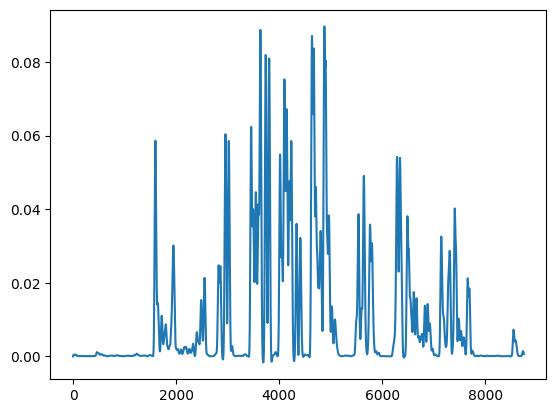

In [18]:
# plot  a single envelope
import matplotlib.pyplot as plt

# timeseries envelope
plt.plot(envtest['envelope_change'])

<Axes: xlabel='t'>

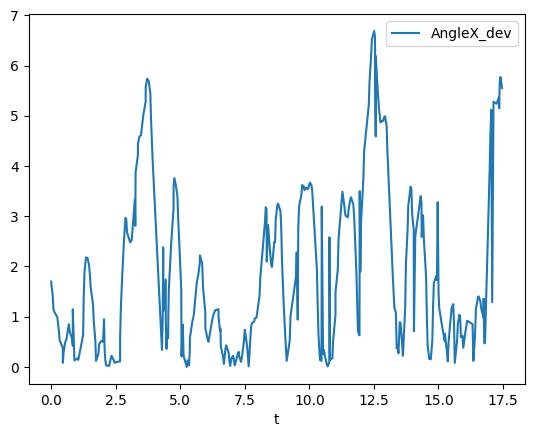

In [19]:
import numpy as np

g = gyrotest.copy()
g['t'] = (pd.to_datetime(g['time']) - pd.to_datetime(g['time']).iloc[0]).dt.total_seconds()
g = g.sort_values('t').reset_index(drop=True)      # MUST be time-ordered before unwrap

ang = g['AngleX(°)'].to_numpy()

# 1. unwrap: removes the ±180 jumps (np.unwrap works in radians)
ang_u = np.degrees(np.unwrap(np.radians(ang)))

# 2. recentre on resting posture (median = the upright baseline), then absolute deviation
ang_dev = np.abs(ang_u - np.median(ang_u))         # |lean away from centre|

g['AngleX_dev'] = ang_dev
g.plot(x='t', y='AngleX_dev')                       # should be smooth, no cliffs

# Resampling gyroscope to match envelope sampling rate

In [ ]:
import numpy as np
import pandas as pd
from scipy.ndimage import uniform_filter1d

def align_gyro_to_envelope(envtest, gyrotest, column='envelope', fs=500.0, smoothing_seconds=0.5):
    """Put speech envelope and gyro on one time grid; return (time, envelope, sway_speed, sway_lean).

    sway_speed = smoothed |angular speed|; sway_lean = smoothed |AngleX deviation from upright|.
    """
    # envelope onto a numeric time grid (seconds)
    envelope = envtest[column].to_numpy()
    envelope_time = envtest['time'].to_numpy().astype(float)
    if np.median(np.diff(envelope_time)) > 0.5:        # too big to be seconds -> ms
        envelope_time = envelope_time / 1000.0

    # gyro: order by time BEFORE unwrap/smooth (rows arrive unsorted)
    gyro = gyrotest.copy()
    gyro['seconds'] = (pd.to_datetime(gyro['time']) - pd.to_datetime(gyro['time']).iloc[0]).dt.total_seconds()
    gyro = gyro.sort_values('seconds').reset_index(drop=True)
    gyro_time = gyro['seconds'].to_numpy()

    angular_speed = gyro[next(c for c in gyro.columns if c.startswith('AsX'))].to_numpy()

    angle = gyro[next(c for c in gyro.columns if c.startswith('AngleX'))].to_numpy()
    angle_unwrapped = np.degrees(np.unwrap(np.radians(angle)))       # remove ±180 cliffs
    lean_angle = np.abs(angle_unwrapped - np.median(angle_unwrapped))

    # clip to overlapping span
    start = max(envelope_time[0], gyro_time[0])
    end   = min(envelope_time[-1], gyro_time[-1])
    keep = (envelope_time >= start) & (envelope_time <= end)
    time = envelope_time[keep]

    # resample gyro onto the envelope grid, smooth on that uniform grid
    window = max(1, int(smoothing_seconds * fs))
    sway_speed = uniform_filter1d(np.abs(np.interp(time, gyro_time, angular_speed)), window)
    sway_lean  = uniform_filter1d(       np.interp(time, gyro_time, lean_angle),      window)

    return time, envelope[keep], sway_speed, sway_lean

time, envelope_clipped, sway_speed, sway_lean = align_gyro_to_envelope(envtest, gyrotest)

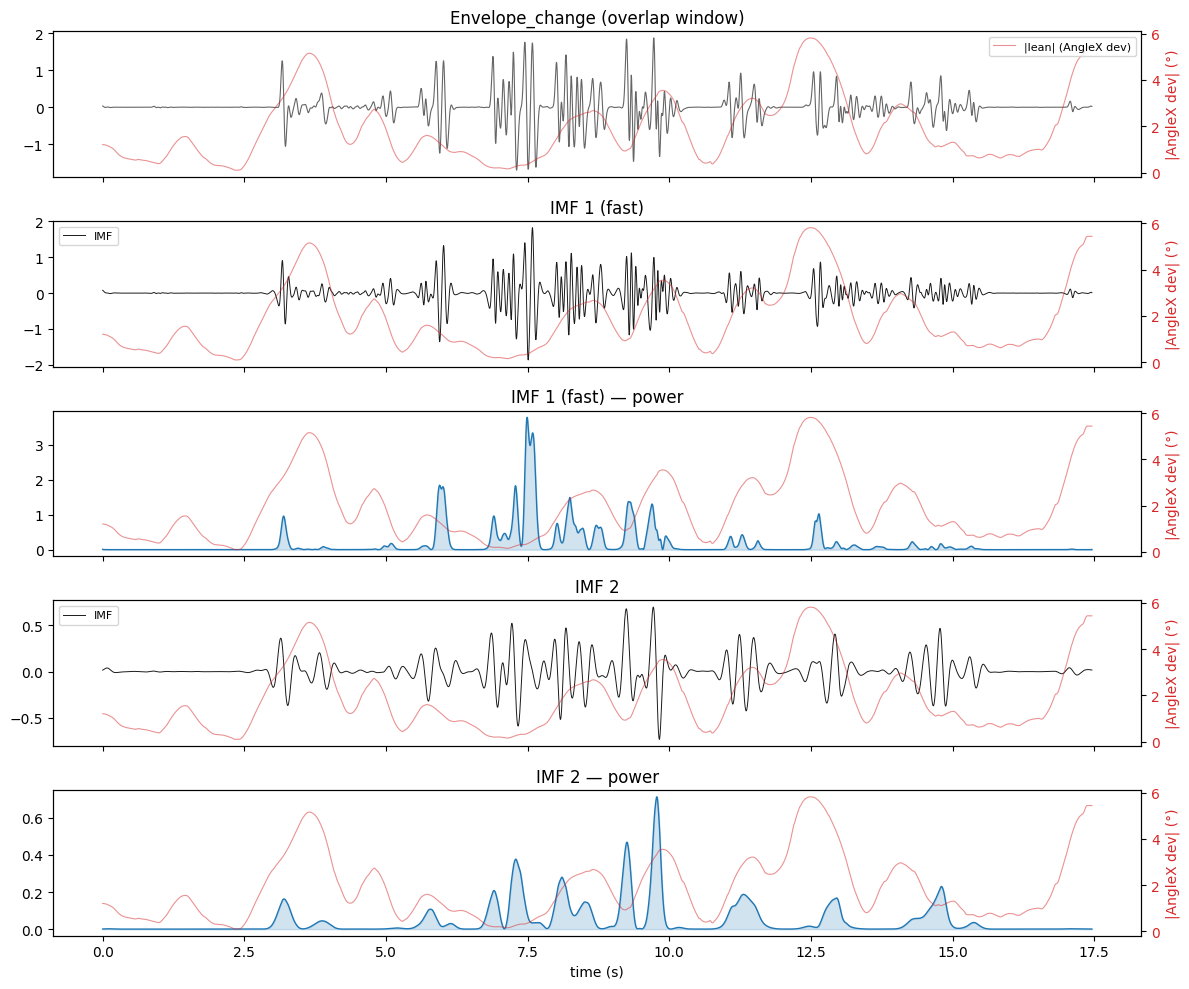

In [27]:
import emd
import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt

# single-trial view: run the alignment, then sift the clipped signal it returns
time, sig, sway_speed, sway_lean = align_gyro_to_envelope(
    envtest, gyrotest, column='envelope_change')

# central differencing to get the change of the signal
sig = np.gradient(sig, time)  # Compute the numerical derivative of the signal

imf_env = emd.sift.mask_sift(sig, max_imfs=2)
amp = np.abs(hilbert(imf_env, axis=0))
pwr = amp ** 2

fig, ax = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

def overlay_lean(a, show_label=False):
    ab = a.twinx()
    ab.plot(time, sway_lean, color='C3', lw=0.8, alpha=0.5, label='|lean| (AngleX dev)')
    ab.set_ylabel('|AngleX dev| (°)', color='C3')
    ab.tick_params(axis='y', labelcolor='C3')
    if show_label:
        ab.legend(loc='upper right', fontsize=8)
    return ab

ax[0].plot(time, sig, color='0.4', lw=0.8)
ax[0].set_title('Envelope_change (overlap window)')
overlay_lean(ax[0], show_label=True)

for k, name in [(0, 'IMF 1 (fast)'), (1, 'IMF 2')]:
    a_imf = ax[1 + 2 * k]
    a_imf.plot(time, imf_env[:, k], color='0.1', lw=0.7, label='IMF')
    a_imf.set_title(name); a_imf.legend(loc='upper left', fontsize=8)
    overlay_lean(a_imf)

    a_pwr = ax[2 + 2 * k]
    a_pwr.plot(time, pwr[:, k], 'C0', lw=1.0, label='power')
    a_pwr.fill_between(time, pwr[:, k], color='C0', alpha=0.2)
    a_pwr.set_title(f'{name} — power')
    overlay_lean(a_pwr)

ax[-1].set_xlabel('time (s)')
plt.tight_layout()

# role out with surrogate analysis (using multisyncpy)

OK now we have comparable timescales. Lets assess coupling between the two signals. We will use the `multisyncpy` for surrogate coupling analysis.

We assess whether the coupling of IMF1 powerseries-lean and IMF2 powerseries-lean is reliable in either conditionbalance, and we also assess within each of these with surrogate analysis.

In [ ]:
import numpy as np, pandas as pd, os, emd
from scipy.signal import hilbert
from scipy.stats import spearmanr

def surrogate_spearman(x, y, n_surrogates=2000, seed=1):
    rho, _ = spearmanr(x, y)
    rng = np.random.default_rng(seed)
    n = len(x)
    null = np.array([spearmanr(x, np.roll(y, rng.integers(n // 20, n - n // 20)))[0]
                     for _ in range(n_surrogates)])
    p = (np.sum(np.abs(null) >= abs(rho)) + 1) / (n_surrogates + 1)
    surr_mean = null.mean()                  # SIGNED -> ~0, the honest baseline
    surr_hi   = np.percentile(null, 97.5)    # upper edge of the chance band
    surr_lo   = np.percentile(null, 2.5)
    return rho, p, surr_mean, surr_hi, surr_lo


gyro_all = pd.read_csv('../../gyroscope.csv')            # load ONCE, outside the loop
meta_all = pd.read_csv('../../metadata.csv')

def analyse_trial(env_path, fs=500.0):
    name = os.path.basename(env_path.replace('\\', '/'))
    parts = name.split('_')
    pair, trial = f"{parts[1]}_{parts[2]}", int(parts[3])

    envtest = pd.read_csv(env_path)
    gyrotest = gyro_all[(gyro_all['group_name'] == pair) &
                        (gyro_all['trial_number'] == trial)]
    if len(gyrotest) < 50:                               # guard: no/short gyro
        return None

    meta = meta_all[(meta_all['pair_id'] == pair) & (meta_all['trial_number'] == trial)]
    condition = meta['clue_giver_condition'].iloc[0] if len(meta) else np.nan

    # align + clip; ask for the SAME column we analyse, so no second clip is needed
    time, env_clip, sway_speed, sway_lean = align_gyro_to_envelope(
        envtest, gyrotest, column='envelope_change', fs=fs)

    # take the difference to get the change of the signal (central differencing)
    sig = np.gradient(env_clip, time)  # Compute the numerical derivative of the signal

    edge = int(1.0 * fs)
    if len(env_clip) <= 2 * edge:                        # guard: too short to trim + test
        return None

    imf = emd.sift.mask_sift(env_clip, max_imfs=2)
    _, inst_freq, inst_amp = emd.spectra.frequency_transform(imf, fs, 'hilbert')
    mean_freq = np.sum(inst_freq * inst_amp**2, 0) / np.sum(inst_amp**2, 0)
    pwr = np.abs(hilbert(imf, axis=0)) ** 2

    lean = sway_lean[edge:-edge]
    row = dict(pair=pair, trial=trial, condition=condition, n=len(lean))
    for k in range(2):
        rho, p, surr_mean, surr_hi, surr_lo = surrogate_spearman(pwr[edge:-edge, k], lean, seed=trial)
        row[f'rho_imf{k+1}']       = rho
        row[f'p_imf{k+1}']         = p
        row[f'surr_mean_imf{k+1}'] = surr_mean
        row[f'surr_hi_imf{k+1}']   = surr_hi
        row[f'surr_lo_imf{k+1}']   = surr_lo
        row[f'mf_imf{k+1}']        = mean_freq[k]
    return row

results = pd.DataFrame([r for f in envelopes if (r := analyse_trial(f)) is not None])
print(f"{len(results)} trials analysed | conditions: {results['condition'].value_counts().to_dict()}")
results.head()

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
C:\Users\Admin\AppData\Roaming\Pytho

80 trials analysed | conditions: {'board': 40, 'ground': 40}


,pair,trial,condition,n,rho_imf1,p_imf1,surr_mean_imf1,surr_hi_imf1,surr_lo_imf1,mf_imf1,rho_imf2,p_imf2,surr_mean_imf2,surr_hi_imf2,surr_lo_imf2,mf_imf2
0,103_203,12,board,7666,-0.126354,0.663168,-0.006739,0.524172,-0.394374,5.632290,0.012257,0.960020,-0.020606,0.452384,-0.411825,2.691743
1,103_203,13,board,7731,0.255099,0.245377,-0.010868,0.398821,-0.335370,6.474885,0.322533,0.085457,-0.022812,0.345407,-0.354863,2.654350
2,103_203,14,board,9992,-0.303627,0.090955,0.014362,0.315507,-0.333787,6.473328,-0.364277,0.029985,0.013636,0.375764,-0.305121,2.854641
3,103_203,15,board,9201,-0.085000,0.626187,0.024187,0.288667,-0.271064,6.224960,-0.025017,0.912044,0.025420,0.337138,-0.369256,2.515800
4,103_203,16,board,6687,0.260392,0.412294,-0.022549,0.499110,-0.489429,6.883708,0.243072,0.401299,-0.019410,0.500461,-0.551022,2.948169


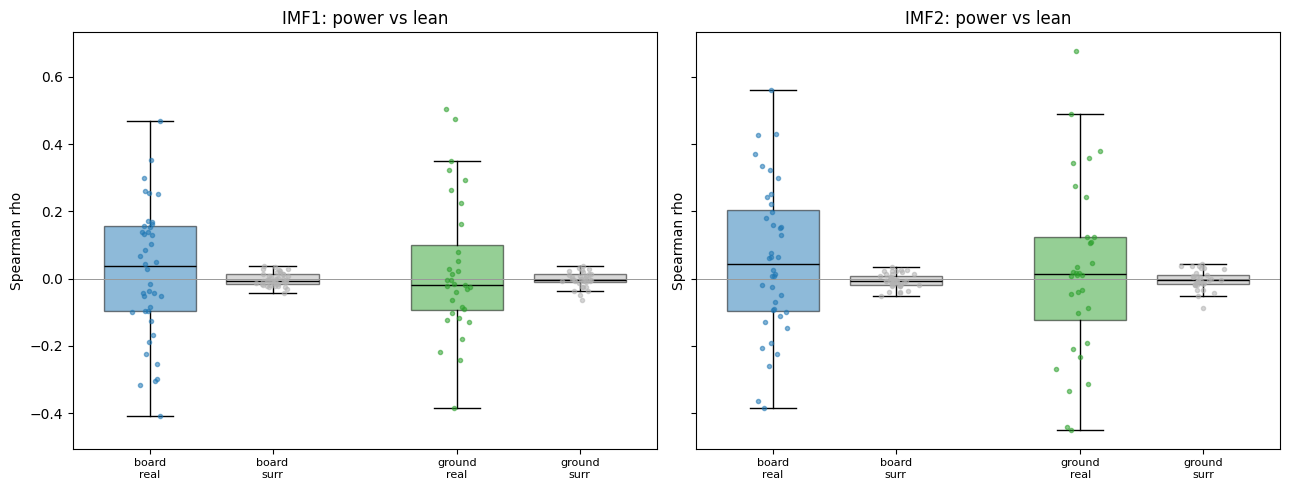

In [23]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
conds = sorted(results['condition'].dropna().unique())      # e.g. ['board','ground']
cond_colors = dict(zip(conds, ['C0', 'C2']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, imf in zip(axes, [1, 2]):
    groups, labels, facecolors = [], [], []
    pos = 0; positions = []
    for cond in conds:
        sub = results[results['condition'] == cond]
        obs = sub[f'rho_imf{imf}'].to_numpy();  obs = obs[np.isfinite(obs)]
        sur = sub[f'surr_mean_imf{imf}'].to_numpy(); sur = sur[np.isfinite(sur)]
        groups += [obs, sur]; positions += [pos, pos + 0.8]
        labels  += [f'{cond}\nreal', f'{cond}\nsurr']
        facecolors += [cond_colors[cond], '0.7']
        pos += 2

    bp = ax.boxplot(groups, positions=positions, widths=0.6,
                    showfliers=False, patch_artist=True, medianprops=dict(color='k'))
    for patch, fc in zip(bp['boxes'], facecolors):
        patch.set_facecolor(fc); patch.set_alpha(0.5)
    for i, (vals, fc) in enumerate(zip(groups, facecolors)):
        ax.scatter(rng.normal(positions[i], 0.05, len(vals)), vals,
                   s=9, color=fc, alpha=0.55, zorder=3)

    ax.axhline(0, color='0.6', lw=0.7)
    ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f'IMF{imf}: power vs lean')
    ax.set_ylabel('Spearman rho')

plt.tight_layout()

In [25]:
import pandas as pd, numpy as np
from scipy.stats import spearmanr

import pandas as pd, numpy as np
from scipy.stats import spearmanr

# load + parse gesture data (if not already in memory)
gest = pd.read_csv('../../gestureclassifications/analysis/kinematic_features.csv')
ids = gest['gesture_id'].str.split('_', expand=True)
gest['pair']  = ids[0] + '_' + ids[1]
gest['trial'] = ids[2].astype(int)


kin = ['duration','hold_time','hand_submovements',
       'hand_mean_submovement_amplitude','hand_peak_speed','hand_mean_speed',
       'hand_peak_acceleration','hand_peak_jerk','elbow_peak_speed',
       'elbow_mean_speed','elbow_peak_jerk','space_use']
per_trial = gest.groupby(['pair','trial'])[kin].mean().reset_index()
per_trial['n_gestures'] = gest.groupby(['pair','trial']).size().values

merged = results.merge(per_trial, on=['pair','trial'], how='inner')
merged['abs_imf1'] = merged['rho_imf1'].abs()
merged['abs_imf2'] = merged['rho_imf2'].abs()

rows = []
for cond, sub in merged.groupby('condition'):
    for f in kin + ['n_gestures']:
        for target in ['rho_imf1','rho_imf2','abs_imf1','abs_imf2']:
            d = sub[[f, target]].dropna()
            if len(d) > 5:
                r, p = spearmanr(d[f], d[target])
                rows.append((cond, f, target, r, p, len(d)))
scan = pd.DataFrame(rows, columns=['condition','feature','target','r','p','n']).sort_values('p')
print(scan.head(20).to_string(index=False))

condition                         feature   target         r        p  n
    board                      n_gestures abs_imf1 -0.387631 0.013461 40
   ground                elbow_mean_speed rho_imf2  0.389099 0.033571 30
    board                  hand_peak_jerk abs_imf1  0.314822 0.047861 40
   ground                      n_gestures abs_imf1 -0.358560 0.051689 30
    board                  hand_peak_jerk abs_imf2  0.308630 0.052666 40
    board                 hand_peak_speed abs_imf1  0.300938 0.059167 40
    board          hand_peak_acceleration abs_imf2  0.296060 0.063610 40
   ground                       space_use abs_imf1  0.341966 0.064364 30
    board          hand_peak_acceleration abs_imf1  0.291557 0.067943 40
   ground                elbow_mean_speed rho_imf1  0.323248 0.081439 30
   ground                      n_gestures abs_imf2 -0.302675 0.103999 30
   ground                elbow_peak_speed rho_imf1  0.301891 0.104943 30
    board hand_mean_submovement_amplitude abs_imf1 

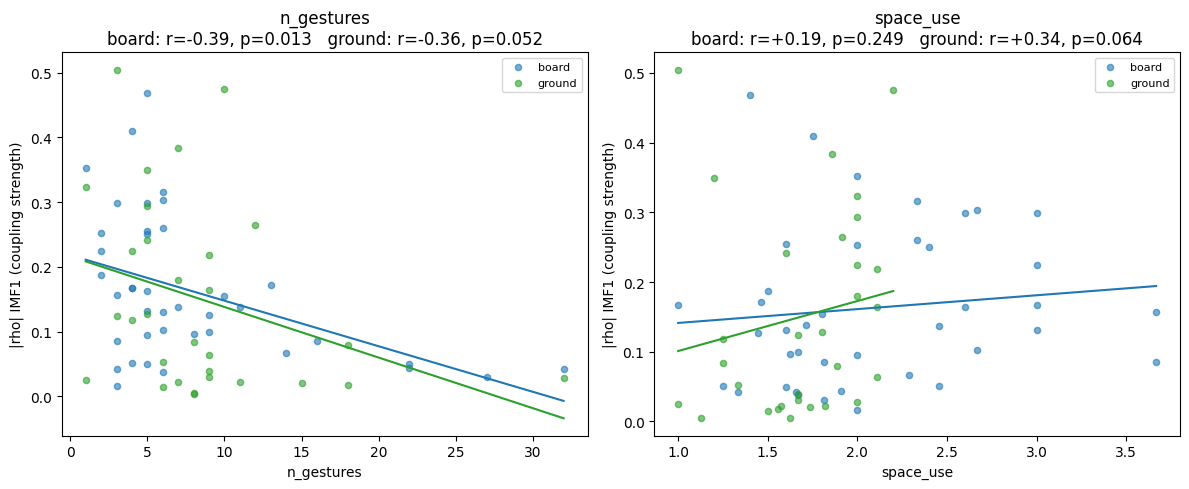

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

conds = sorted(merged['condition'].dropna().unique())
colors = dict(zip(conds, ['C0', 'C2']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, feat in zip(axes, ['n_gestures', 'space_use']):
    notes = []
    for cond in conds:
        d = merged[merged['condition'] == cond][[feat, 'abs_imf1']].dropna()
        x, y = d[feat].to_numpy(), d['abs_imf1'].to_numpy()
        if len(x) < 5:
            continue
        r, p = spearmanr(x, y)
        ax.scatter(x, y, s=20, alpha=0.6, color=colors[cond], label=cond)
        b, a = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, a + b * xs, color=colors[cond], lw=1.5)
        notes.append(f'{cond}: r={r:+.2f}, p={p:.3f}')
    ax.set_xlabel(feat); ax.set_ylabel('|rho| IMF1 (coupling strength)')
    ax.set_title(f'{feat}\n' + '   '.join(notes))
    ax.legend(fontsize=8)
plt.tight_layout()

n_gestures vs |rho|:   SignificanceResult(statistic=nan, pvalue=nan)
trial length vs |rho|: SignificanceResult(statistic=nan, pvalue=nan)
space_use vs |rho|, controlling n_gestures:  r=+0.30, p=0.011
